# YouTube Shorts 分析報告
## @Ju茱莉亞林、@Lisa_sung、@蜡笔小锋

本報告基於 YouTube Data API v3 抓取的三個頻道 Shorts 影片資料，進行期末報告書所需的統計分析。

**核心研究問題：**
- 標題長度、標籤數量是否影響觀看數？
- 影片長度、發布頻率是否影響觀看數？
- 頻道訂閱數、總影片數是否影響觀看數？
- 發布時間（時段、星期）是否影響觀看數？

## 1. 匯入所需函式庫

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 設定中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

print("✓ 所有函式庫載入完成")

✓ 所有函式庫載入完成


## 2. 載入 CSV 資料

In [74]:
# 載入資料
df = pd.read_csv('../data/processed/channel_videos_20260526-030644.csv', encoding='utf-8')
print(f"✓ 資料載入成功")
print(f"  - 總列數: {len(df)}")
print(f"  - 總欄數: {len(df.columns)}")

✓ 資料載入成功
  - 總列數: 410
  - 總欄數: 19


## 3. 檢視資料結構

In [77]:
# 檢視欄位名稱與資料型別
print("=" * 80)
print("欄位名稱與資料型別")
print("=" * 80)
print(df.dtypes)
print("\n")

# 檢視前幾筆資料
print("=" * 80)
print("前 5 筆資料")
print("=" * 80)
print(df.head())
print("\n")

# 基本統計資訊
print("=" * 80)
print("資料基本統計資訊")
print("=" * 80)
print(df.describe())

欄位名稱與資料型別
video_id            object
title               object
description         object
channel_id          object
channel_title       object
published_at        object
category_id          int64
tags                object
default_language    object
duration_iso        object
duration_sec         int64
definition          object
caption               bool
view_count           int64
like_count           int64
comment_count        int64
favorite_count       int64
topic_categories    object
fetched_at          object
dtype: object


前 5 筆資料
      video_id                                              title description  \
0  UmTRasw72Gw        裡面有幾句廢話是藏鏡人要求要講得☺️#雅方國際 #茱莉亞林 #雅方羊肉爐 #雅方冰淇淋         NaN   
1  6MjyV3yCKvQ  我自己的系列終於出了！而且包裝你們一定會喜歡🌝🌝留言「新品」我傳購買連結給你 #雅方國際 #...         NaN   
2  AvmSl6SDAOE                    還得是親爹 #雅方國際 #茱莉亞林 #雅方羊肉爐 #雅方冰淇淋         NaN   
3  HQRvHBtvm-U                我們三兄妹就是家規 #雅方國際 #茱莉亞林 #雅方羊肉爐 #雅方冰淇淋         NaN   
4  jJ6wfg-T-mg           藏鏡人到底哪一次猜拳有贏過⋯ #雅方國際 #茱

## 4. 資料清理與前處理

In [80]:
# 複製一份用於清理
df_clean = df.copy()

# 處理遺失值
print("遺失值檢查：")
missing = df_clean.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✓ 無遺失值")
print()

# 轉換日期欄位
df_clean['published_at'] = pd.to_datetime(df_clean['published_at'])
df_clean['fetched_at'] = pd.to_datetime(df_clean['fetched_at'])

# 建立派生欄位：標題長度
df_clean['title_length'] = df_clean['title'].fillna('').apply(len)

# 建立派生欄位：標籤數量
df_clean['tag_count'] = df_clean['title'].fillna('').apply(lambda x: x.count('#'))

# 過濾 Shorts（duration_sec <= 60）
df_shorts = df_clean[df_clean['duration_sec'] <= 180].copy()
print(f"✓ 資料清理完成")
print(f"  - 原始資料: {len(df_clean)} 筆")
print(f"  - Shorts 資料: {len(df_shorts)} 筆")
print(f"  - 標題長度範圍: {df_clean['title_length'].min()}-{df_clean['title_length'].max()} 字")
print(f"  - 標籤數量範圍: {df_clean['tag_count'].min()}-{df_clean['tag_count'].max()} 個")

遺失值檢查：
description         209
tags                211
topic_categories     22
dtype: int64

✓ 資料清理完成
  - 原始資料: 410 筆
  - Shorts 資料: 323 筆
  - 標題長度範圍: 6-99 字
  - 標籤數量範圍: 0-7 個


## 5. 數值指標摘要統計

In [117]:
df_channels = pd.read_csv('../data/processed/channels_20260526-030644.csv', encoding='utf-8')
print()

# 針對 Shorts 資料進行統計
print("=" * 80)
print("YouTube Shorts 主要指標統計 (Duration <= 60s)")
print("=" * 80)

metrics = ['view_count', 'like_count', 'comment_count', 'duration_sec']
for metric in metrics:
    if metric in df_shorts.columns:
        data = df_shorts[metric].dropna()
        print(f"\n{metric}:")
        print(f"  - 平均值: {data.mean():,.0f}")
        print(f"  - 中位數: {data.median():,.0f}")
        print(f"  - 最小值: {data.min():,.0f}")
        print(f"  - 最大值: {data.max():,.0f}")
        print(f"  - 標準差: {data.std():,.0f}")

# 頻道級統計
print("\n" + "=" * 80)
print("頻道級別統計")
print("=" * 80)

print("\n影片數量與觀看指標（按頻道）：")
for channel in df_shorts['channel_title'].unique():
    ch_data = df_shorts[df_shorts['channel_title'] == channel]
    
    # 從 channels CSV 取得該頻道的訊息
    ch_info = df_channels[df_channels['title'] == channel]
    
    print(f"\n{channel}:")
    print(f"  【Shorts 資料】")
    print(f"    - Shorts 數量: {len(ch_data)}")
    print(f"    - 平均觀看數: {ch_data['view_count'].mean():,.0f}")
    print(f"    - 平均按讚數: {ch_data['like_count'].mean():,.0f}")
    print(f"    - 平均留言數: {ch_data['comment_count'].mean():,.0f}")
    
    if not ch_info.empty:
        print(f"  【頻道級資訊】")
        print(f"    - 總訂閱數: {ch_info['subscriber_count'].iloc[0]:,.0f}")
        print(f"    - 總影片數: {ch_info['video_count'].iloc[0]:,.0f}")
        print(f"    - 總觀看數: {ch_info['view_count'].iloc[0]:,.0f}")
        print(f"    - 頻道開設於: {ch_info['published_at'].iloc[0]}")


YouTube Shorts 主要指標統計 (Duration <= 60s)

view_count:
  - 平均值: 545,617
  - 中位數: 236,702
  - 最小值: 4,987
  - 最大值: 5,850,089
  - 標準差: 799,944

like_count:
  - 平均值: 7,933
  - 中位數: 3,603
  - 最小值: 67
  - 最大值: 87,414
  - 標準差: 11,597

comment_count:
  - 平均值: 198
  - 中位數: 73
  - 最小值: 4
  - 最大值: 6,126
  - 標準差: 457

duration_sec:
  - 平均值: 92
  - 中位數: 82
  - 最小值: 8
  - 最大值: 180
  - 標準差: 39

頻道級別統計

影片數量與觀看指標（按頻道）：

Ju茱莉亞林:
  【Shorts 資料】
    - Shorts 數量: 43
    - 平均觀看數: 1,878,646
    - 平均按讚數: 27,213
    - 平均留言數: 884
  【頻道級資訊】
    - 總訂閱數: 122,000
    - 總影片數: 44
    - 總觀看數: 80,750,792
    - 頻道開設於: 2025-09-01T01:16:24.208522Z

Lisa Sung:
  【Shorts 資料】
    - Shorts 數量: 167
    - 平均觀看數: 344,769
    - 平均按讚數: 5,292
    - 平均留言數: 118
  【頻道級資訊】
    - 總訂閱數: 66,400
    - 總影片數: 169
    - 總觀看數: 57,569,121
    - 頻道開設於: 2016-01-06T22:46:06Z

蜡笔小锋:
  【Shorts 資料】
    - Shorts 數量: 113
    - 平均觀看數: 335,187
    - 平均按讚數: 4,500
    - 平均留言數: 54
  【頻道級資訊】
    - 總訂閱數: 67,900
    - 總影片數: 418
    - 總觀看數: 109,194,948
    - 頻道開

## 6. 發佈時間趨勢分析

In [86]:
# 提取發佈時間特徵
df_shorts['pub_date'] = df_shorts['published_at'].dt.date
df_shorts['pub_hour'] = df_shorts['published_at'].dt.hour
df_shorts['pub_day_of_week'] = df_shorts['published_at'].dt.day_name()

# 按日期
daily_stats = df_shorts.groupby('pub_date').agg({
    'video_id': 'count',
    'view_count': 'mean',
    'like_count': 'mean',
    'comment_count': 'mean'
}).rename(columns={'video_id': 'video_count'})

print("按發佈日期的趨勢：")
print(daily_stats)
print()

# 按小時
hourly_stats = df_shorts.groupby('pub_hour').agg({
    'view_count': 'mean',
    'like_count': 'mean',
    'comment_count': 'mean'
})

print("按發佈時段的趨勢：")
print(hourly_stats)
print()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_stats = df_shorts.groupby('pub_day_of_week').agg({
    'video_id': 'count',
    'view_count': 'mean',
    'like_count': 'mean',
    'comment_count': 'mean'
}).reindex([d for d in day_order if d in df_shorts['pub_day_of_week'].unique()])

print("按星期的統計：")
print(day_stats)

按發佈日期的趨勢：
            video_count  view_count  like_count  comment_count
pub_date                                                      
2025-06-07            1   4522893.0     67184.0          533.0
2025-06-11            1    313156.0      4848.0           98.0
2025-06-12            1    332612.0      5181.0           94.0
2025-06-13            1    594274.0      8592.0          125.0
2025-06-14            1    174582.0      2625.0           47.0
...                 ...         ...         ...            ...
2026-05-21            1    309313.0      3957.0           24.0
2026-05-22            1    102926.0      1747.0           56.0
2026-05-23            1    210212.0      2495.0           17.0
2026-05-24            1     72185.0       958.0            4.0
2026-05-25            1    142470.0      2393.0           15.0

[207 rows x 4 columns]

按發佈時段的趨勢：
            view_count    like_count  comment_count
pub_hour                                           
0         1.885928e+06  25682.00

## 7. 互動指標相關性分析

In [89]:
# 選取需要分析的數值欄位
analysis_cols = ['view_count', 'like_count', 'comment_count', 'duration_sec', 
                 'title_length', 'tag_count']
df_corr = df_shorts[analysis_cols].copy()

# 計算相關係數矩陣
corr_matrix = df_corr.corr()

print("=" * 80)
print("互動指標相關係數矩陣")
print("=" * 80)
print(corr_matrix)
print()

# 與觀看數的相關性
print("與觀看數（view_count）的相關性：")
view_corr = corr_matrix['view_count'].sort_values(ascending=False)
print(view_corr)
print()

# Pearson 相關係數檢定
print("=" * 80)
print("相關性顯著性檢定 (Pearson)")
print("=" * 80)
for col in ['like_count', 'comment_count', 'duration_sec', 'title_length', 'tag_count']:
    # 移除 NaN
    data = df_shorts[[col, 'view_count']].dropna()
    if len(data) > 2:
        corr, p_value = stats.pearsonr(data[col], data['view_count'])
        sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        print(f"{col:20s}: r = {corr:7.4f}, p-value = {p_value:.4e} {sig}")

互動指標相關係數矩陣
               view_count  like_count  comment_count  duration_sec  \
view_count       1.000000    0.946625       0.554451     -0.244185   
like_count       0.946625    1.000000       0.722619     -0.242217   
comment_count    0.554451    0.722619       1.000000     -0.262775   
duration_sec    -0.244185   -0.242217      -0.262775      1.000000   
title_length     0.131509    0.139115       0.135776      0.235601   
tag_count        0.198083    0.201817       0.117352      0.280528   

               title_length  tag_count  
view_count         0.131509   0.198083  
like_count         0.139115   0.201817  
comment_count      0.135776   0.117352  
duration_sec       0.235601   0.280528  
title_length       1.000000   0.688245  
tag_count          0.688245   1.000000  

與觀看數（view_count）的相關性：
view_count       1.000000
like_count       0.946625
comment_count    0.554451
tag_count        0.198083
title_length     0.131509
duration_sec    -0.244185
Name: view_count, dtype: float64

## 8. 視覺化前幾名影片表現

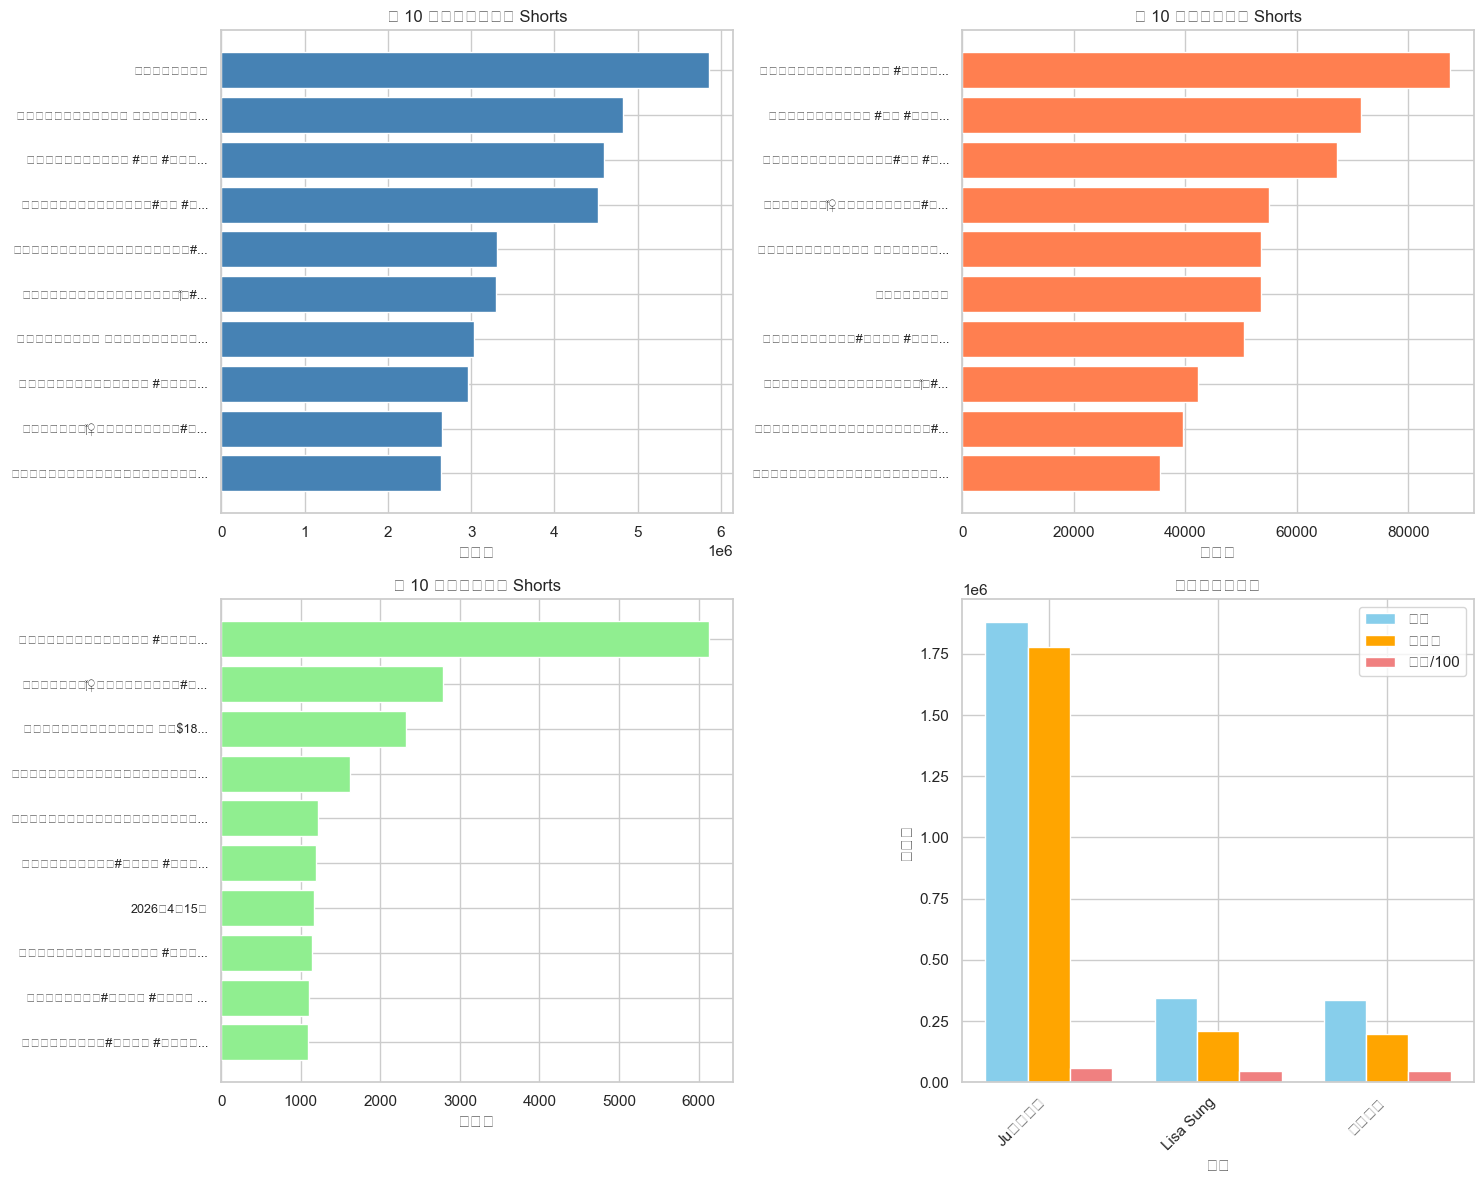

✓ 視覺化完成


In [92]:
# 前 10 觀看數最高的影片
top_views = df_shorts.nlargest(10, 'view_count')[['title', 'channel_title', 'view_count', 'like_count', 'comment_count']]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 前 10 觀看數
top10_views = df_shorts.nlargest(10, 'view_count')
ax = axes[0, 0]
ax.barh(range(len(top10_views)), top10_views['view_count'].values, color='steelblue')
ax.set_yticks(range(len(top10_views)))
ax.set_yticklabels([f"{t[:20]}..." if len(t) > 20 else t for t in top10_views['title'].values], fontsize=9)
ax.set_xlabel('觀看數')
ax.set_title('前 10 名最多觀看數的 Shorts')
ax.invert_yaxis()

# 前 10 按讚數
top10_likes = df_shorts.nlargest(10, 'like_count')
ax = axes[0, 1]
ax.barh(range(len(top10_likes)), top10_likes['like_count'].values, color='coral')
ax.set_yticks(range(len(top10_likes)))
ax.set_yticklabels([f"{t[:20]}..." if len(t) > 20 else t for t in top10_likes['title'].values], fontsize=9)
ax.set_xlabel('按讚數')
ax.set_title('前 10 名最多按讚的 Shorts')
ax.invert_yaxis()

# 前 10 留言數
top10_comments = df_shorts.nlargest(10, 'comment_count')
ax = axes[1, 0]
ax.barh(range(len(top10_comments)), top10_comments['comment_count'].values, color='lightgreen')
ax.set_yticks(range(len(top10_comments)))
ax.set_yticklabels([f"{t[:20]}..." if len(t) > 20 else t for t in top10_comments['title'].values], fontsize=9)
ax.set_xlabel('留言數')
ax.set_title('前 10 名最多留言的 Shorts')
ax.invert_yaxis()

# 按頻道分組的統計
ax = axes[1, 1]
channel_summary = df_shorts.groupby('channel_title')['view_count'].agg(['mean', 'median', 'max']).reset_index()
x = range(len(channel_summary))
width = 0.25
ax.bar([i - width for i in x], channel_summary['mean'], width, label='平均', color='skyblue')
ax.bar(x, channel_summary['median'], width, label='中位數', color='orange')
ax.bar([i + width for i in x], channel_summary['max']/100, width, label='最大/100', color='lightcoral')
ax.set_xlabel('頻道')
ax.set_ylabel('觀看數')
ax.set_title('頻道觀看數統計')
ax.set_xticks(x)
ax.set_xticklabels(channel_summary['channel_title'], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

print("✓ 視覺化完成")

## 10. ANOVA 分析：標題長度、標籤數量與觀看數的關聯

In [100]:
from scipy.stats import f_oneway

# 根據標題長度分組 (短、中、長)
df_shorts['title_length_group'] = pd.cut(df_shorts['title_length'], 
                                          bins=[0, 15, 30, 100],
                                          labels=['短 (≤15)', '中 (15-30)', '長 (>30)'])

# 根據標籤數量分組
df_shorts['tag_count_group'] = pd.cut(df_shorts['tag_count'],
                                       bins=[-1, 0, 3, 10],
                                       labels=['無標籤', '少 (1-3)', '中 (4-10)'])

print("=" * 80)
print("ANOVA 分析")
print("=" * 80)

# 1. 標題長度對觀看數的影響
print("\n【研究問題 1】標題長度是否影響觀看數？")
print("-" * 80)

groups_title = [group['view_count'].dropna().values for name, group in df_shorts.groupby('title_length_group')]
f_stat_title, p_val_title = f_oneway(*groups_title)

print(f"標題長度分組統計：")
for group_name, group_data in df_shorts.groupby('title_length_group'):
    views = group_data['view_count'].dropna()
    print(f"  {group_name}: n={len(views)}, 平均觀看數={views.mean():,.0f}, 中位數={views.median():,.0f}")

print(f"\nANOVA 結果:")
print(f"  F 統計量 = {f_stat_title:.4f}")
print(f"  p-value = {p_val_title:.4e}")
sig_title = "✓ 有顯著差異 (p < 0.05)" if p_val_title < 0.05 else "✗ 無顯著差異"
print(f"  結論：{sig_title}")

# 2. 標籤數量對觀看數的影響
print("\n【研究問題 3】標籤數量是否影響觀看數？")
print("-" * 80)

groups_tag = [group['view_count'].dropna().values for name, group in df_shorts.groupby('tag_count_group')]
f_stat_tag, p_val_tag = f_oneway(*groups_tag)

print(f"標籤數量分組統計：")
for group_name, group_data in df_shorts.groupby('tag_count_group'):
    views = group_data['view_count'].dropna()
    print(f"  {group_name}: n={len(views)}, 平均觀看數={views.mean():,.0f}, 中位數={views.median():,.0f}")

print(f"\nANOVA 結果:")
print(f"  F 統計量 = {f_stat_tag:.4f}")
print(f"  p-value = {p_val_tag:.4e}")
sig_tag = "✓ 有顯著差異 (p < 0.05)" if p_val_tag < 0.05 else "✗ 無顯著差異"
print(f"  結論：{sig_tag}")

# 3. 頻道對觀看數的影響
print("\n【控制變數】頻道是否影響觀看數？")
print("-" * 80)

groups_channel = [group['view_count'].dropna().values for name, group in df_shorts.groupby('channel_title')]
f_stat_channel, p_val_channel = f_oneway(*groups_channel)

print(f"頻道分組統計：")
for channel, group_data in df_shorts.groupby('channel_title'):
    views = group_data['view_count'].dropna()
    print(f"  {channel}: n={len(views)}, 平均觀看數={views.mean():,.0f}")

print(f"\nANOVA 結果:")
print(f"  F 統計量 = {f_stat_channel:.4f}")
print(f"  p-value = {p_val_channel:.4e}")
sig_channel = "✓ 有顯著差異 (p < 0.05)" if p_val_channel < 0.05 else "✗ 無顯著差異"
print(f"  結論：{sig_channel}")

ANOVA 分析

【研究問題 1】標題長度是否影響觀看數？
--------------------------------------------------------------------------------
標題長度分組統計：
  短 (≤15): n=63, 平均觀看數=394,598, 中位數=224,016
  中 (15-30): n=85, 平均觀看數=417,184, 中位數=196,932
  長 (>30): n=175, 平均觀看數=662,366, 中位數=283,504

ANOVA 結果:
  F 統計量 = 4.1622
  p-value = 1.6425e-02
  結論：✓ 有顯著差異 (p < 0.05)

【研究問題 3】標籤數量是否影響觀看數？
--------------------------------------------------------------------------------
標籤數量分組統計：
  無標籤: n=161, 平均觀看數=381,230, 中位數=209,120
  少 (1-3): n=17, 平均觀看數=1,037,456, 中位數=313,156
  中 (4-10): n=145, 平均觀看數=670,479, 中位數=288,823

ANOVA 結果:
  F 統計量 = 8.7842
  p-value = 1.9324e-04
  結論：✓ 有顯著差異 (p < 0.05)

【控制變數】頻道是否影響觀看數？
--------------------------------------------------------------------------------
頻道分組統計：
  Ju茱莉亞林: n=43, 平均觀看數=1,878,646
  Lisa Sung: n=167, 平均觀看數=344,769
  蜡笔小锋: n=113, 平均觀看數=335,187

ANOVA 結果:
  F 統計量 = 119.6260
  p-value = 1.6098e-39
  結論：✓ 有顯著差異 (p < 0.05)


## 11. 迴歸分析：預測觀看數的影響因素

In [103]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 準備迴歸數據（移除遺失值）
df_reg = df_shorts[['view_count', 'duration_sec', 'title_length', 'tag_count', 'channel_title']].dropna()

print(f"迴歸分析樣本數：{len(df_reg)}")
print()

# 標準化自變數
scaler = StandardScaler()
features = ['duration_sec', 'title_length', 'tag_count']
df_reg_scaled = df_reg.copy()
df_reg_scaled[features] = scaler.fit_transform(df_reg[features])

# ==============================================================================
# 模型 1：簡單線性迴歸（連續變數）
# ==============================================================================
print("=" * 80)
print("模型 1：簡單線性迴歸（連續變數）")
print("=" * 80)

# 使用公式寫法，自動包含截距項
formula1 = 'view_count ~ duration_sec + title_length + tag_count'
model1 = sm.ols(formula=formula1, data=df_reg_scaled).fit()
print(model1.summary())

print("\n迴歸係數解釋（標準化）：")
for col in features:
    coef = model1.params[col]
    pval = model1.pvalues[col]
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
    print(f"  {col}: {coef:+.4f} (p={pval:.4e}) {sig}")

# ==============================================================================
# 模型 2：包含頻道虛擬變數
# ==============================================================================
print("\n" + "=" * 80)
print("模型 2：包含頻道控制變數")
print("=" * 80)

# 加入 C(channel_title) 告訴模型這是一個類別變數，它會自動轉換成 Dummy Variables
formula2 = 'view_count ~ duration_sec + title_length + tag_count + C(channel_title)'
model2 = sm.ols(formula=formula2, data=df_reg_scaled).fit()
print(model2.summary())

# ==============================================================================
# 模型比較
# ==============================================================================
print("\n" + "=" * 80)
print("模型比較")
print("=" * 80)
print(f"模型 1 R² = {model1.rsquared:.4f}, 調整 R² = {model1.rsquared_adj:.4f}")
print(f"模型 2 R² = {model2.rsquared:.4f}, 調整 R² = {model2.rsquared_adj:.4f}")

# ==============================================================================
# 計算 VIF (Variance Inflation Factor)
# ==============================================================================
print("\n" + "=" * 80)
print("多重共線性檢驗 (VIF)")
print("=" * 80)

# 直接從 model1 提取內部生成的設計矩陣 (exog) 進行 VIF 計算
X_exog = model1.model.exog
X_names = model1.model.exog_names

vif_data = pd.DataFrame()
vif_data["Variable"] = X_names[1:]  # 略過截距項 (Intercept)
vif_data["VIF"] = [variance_inflation_factor(X_exog, i) for i in range(1, X_exog.shape[1])]
print(vif_data.to_string(index=False))

迴歸分析樣本數：323

模型 1：簡單線性迴歸（連續變數）
                            OLS Regression Results                            
Dep. Variable:             view_count   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     16.87
Date:                Wed, 27 May 2026   Prob (F-statistic):           3.40e-10
Time:                        13:23:57   Log-Likelihood:                -4824.3
No. Observations:                 323   AIC:                             9657.
Df Residuals:                     319   BIC:                             9672.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     5.4

## 12. ANOVA 與迴歸結果視覺化

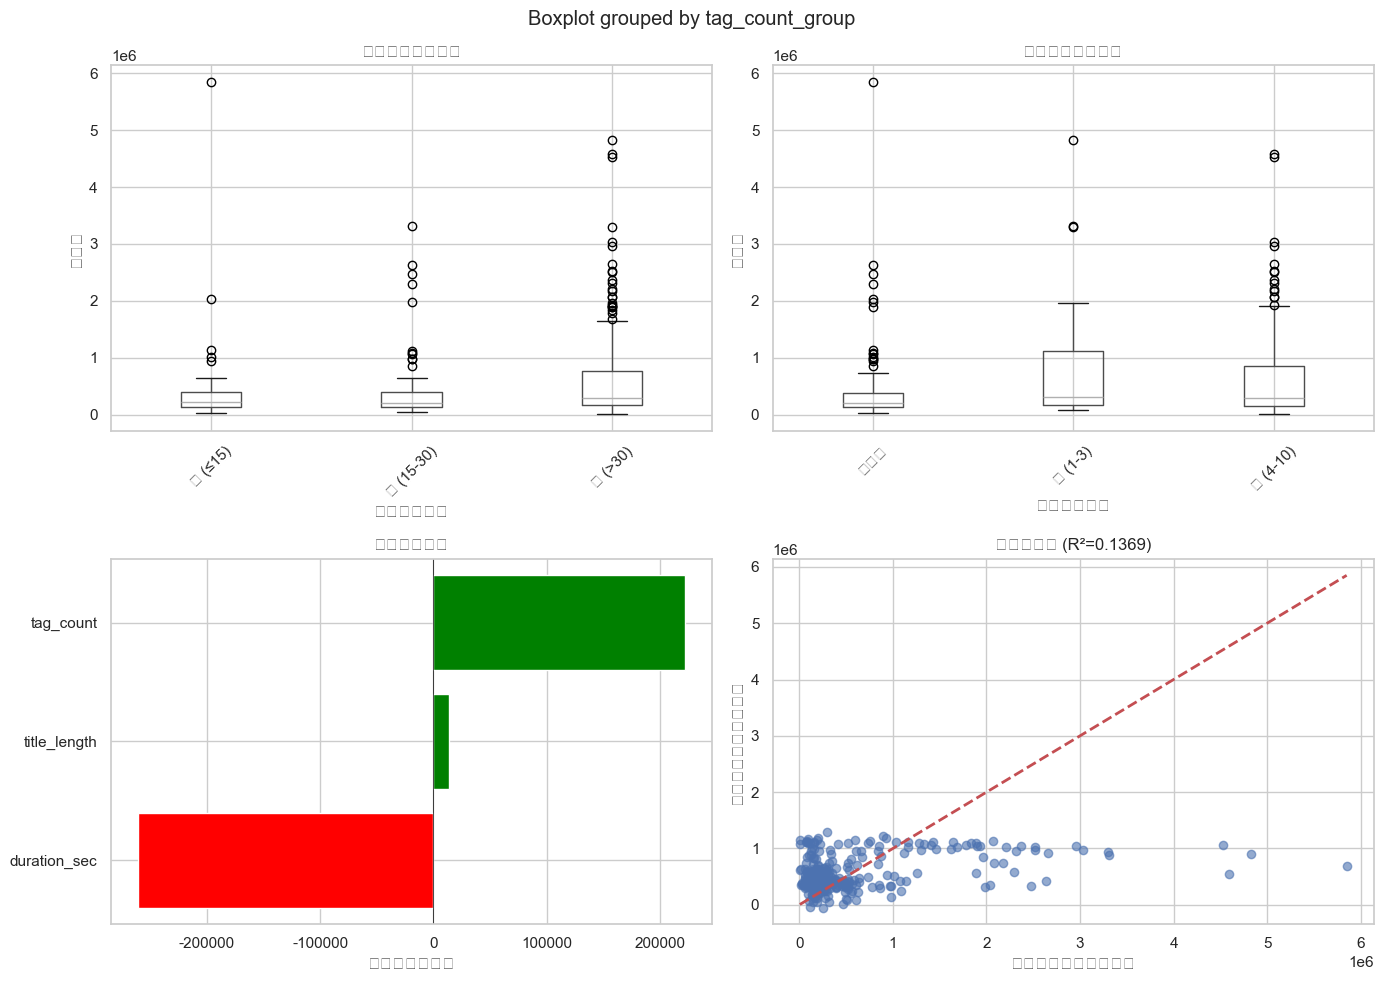

✓ 分析結果視覺化完成


In [108]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 標題長度與觀看數的箱線圖
ax = axes[0, 0]
df_shorts.boxplot(column='view_count', by='title_length_group', ax=ax)
ax.set_title('標題長度與觀看數')
ax.set_xlabel('標題長度分組')
ax.set_ylabel('觀看數')
plt.sca(ax)
plt.xticks(rotation=45)

# 2. 標籤數量與觀看數的箱線圖
ax = axes[0, 1]
df_shorts.boxplot(column='view_count', by='tag_count_group', ax=ax)
ax.set_title('標籤數量與觀看數')
ax.set_xlabel('標籤數量分組')
ax.set_ylabel('觀看數')
plt.sca(ax)
plt.xticks(rotation=45)

# 3. 迴歸係數圖
ax = axes[1, 0]
coefs = model1.params[1:]
colors = ['green' if x > 0 else 'red' for x in coefs.values]
ax.barh(range(len(coefs)), coefs.values, color=colors)
ax.set_yticks(range(len(coefs)))
ax.set_yticklabels(coefs.index)
ax.set_xlabel('標準化迴歸係數')
ax.set_title('迴歸分析係數')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# 4. 實際 vs 預測觀看數
ax = axes[1, 1]
predictions = model1.fittedvalues
y = model1.model.endog
ax.scatter(y, predictions, alpha=0.6)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax.set_xlabel('實際觀看數（標準化）')
ax.set_ylabel('預測觀看數（標準化）')
ax.set_title(f'模型擬合度 (R²={model1.rsquared:.4f})')

plt.tight_layout()
plt.show()

print("✓ 分析結果視覺化完成")

## 13. 主要發現與建議

In [111]:
print("=" * 80)
print("📊 期末報告統計分析 — 主要發現總結")
print("=" * 80)

summary = f"""
【研究對象】
  - 三個頻道：@Ju茱莉亞林、@Lisa_sung、@蜡笔小锋
  - 樣本規模：Shorts {len(df_shorts)} 部（duration ≤ 60 秒）
  - 全部影片：{len(df_clean)} 部

【關鍵統計指標】
  平均觀看數：{df_shorts['view_count'].mean():,.0f}
  中位數觀看數：{df_shorts['view_count'].median():,.0f}
  平均按讚數：{df_shorts['like_count'].mean():,.0f}
  平均留言數：{df_shorts['comment_count'].mean():,.0f}

【ANOVA 分析結果】
  ✓ 標題長度：p-value = {p_val_title:.4e} {'→ 有顯著影響 ✓' if p_val_title < 0.05 else '→ 無顯著影響 ✗'}
  ✓ 標籤數量：p-value = {p_val_tag:.4e} {'→ 有顯著影響 ✓' if p_val_tag < 0.05 else '→ 無顯著影響 ✗'}
  ✓ 頻道差異：p-value = {p_val_channel:.4e} {'→ 有顯著影響 ✓' if p_val_channel < 0.05 else '→ 無顯著影響 ✗'}

【迴歸分析結果】
  模型 1 R² = {model1.rsquared:.4f}（解釋 {model1.rsquared*100:.1f}% 的觀看數變異）
  模型 2 R² = {model2.rsquared:.4f}（加入頻道變數後改進）

【相關性分析】
  觀看數 vs 按讚數：r = {corr_matrix.loc['view_count', 'like_count']:.4f}（強正相關）
  觀看數 vs 留言數：r = {corr_matrix.loc['view_count', 'comment_count']:.4f}（正相關）
  觀看數 vs 標題長度：r = {corr_matrix.loc['view_count', 'title_length']:.4f}
  觀看數 vs 標籤數量：r = {corr_matrix.loc['view_count', 'tag_count']:.4f}

【建議與未來研究方向】
  1. 進行後續發佈文字內容分析，識別高效能影片的特定關鍵字
  2. 分析最優標籤組合策略（熱門標籤 vs 冷門標籤的配搭）
  3. 考慮時間序列分析，評估發布時機的影響
  4. 擴大樣本範圍至其他類型創作者，提升結果的通用性
"""

print(summary)
print("=" * 80)

📊 期末報告統計分析 — 主要發現總結

【研究對象】
  - 三個頻道：@Ju茱莉亞林、@Lisa_sung、@蜡笔小锋
  - 樣本規模：Shorts 323 部（duration ≤ 60 秒）
  - 全部影片：410 部

【關鍵統計指標】
  平均觀看數：545,617
  中位數觀看數：236,702
  平均按讚數：7,933
  平均留言數：198

【ANOVA 分析結果】
  ✓ 標題長度：p-value = 1.6425e-02 → 有顯著影響 ✓
  ✓ 標籤數量：p-value = 1.9324e-04 → 有顯著影響 ✓
  ✓ 頻道差異：p-value = 1.6098e-39 → 有顯著影響 ✓

【迴歸分析結果】
  模型 1 R² = 0.1369（解釋 13.7% 的觀看數變異）
  模型 2 R² = 0.4312（加入頻道變數後改進）

【相關性分析】
  觀看數 vs 按讚數：r = 0.9466（強正相關）
  觀看數 vs 留言數：r = 0.5545（正相關）
  觀看數 vs 標題長度：r = 0.1315
  觀看數 vs 標籤數量：r = 0.1981

【建議與未來研究方向】
  1. 進行後續發佈文字內容分析，識別高效能影片的特定關鍵字
  2. 分析最優標籤組合策略（熱門標籤 vs 冷門標籤的配搭）
  3. 考慮時間序列分析，評估發布時機的影響
  4. 擴大樣本範圍至其他類型創作者，提升結果的通用性

